In [29]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import UNX_to_UTC
from helper import find_closest_index_dt

import math
from scipy.interpolate import interp1d

from numpy.linalg import LinAlgError

import pandas as pd

In [30]:
from detection_helper import *

In [31]:
times_arr, freq_arr, data_arr = return_arr('2023-08-19', '2023-08-20')

23-Dec-25 22:59:24: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
23-Dec-25 22:59:24: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
23-Dec-25 22:59:25: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
23-Dec-25 22:59:25: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
23-Dec-25 22:59:25: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
23-Dec-25 22:59:26: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
23-Dec-25 22:59:26: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
23-Dec-25 22:59:29: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


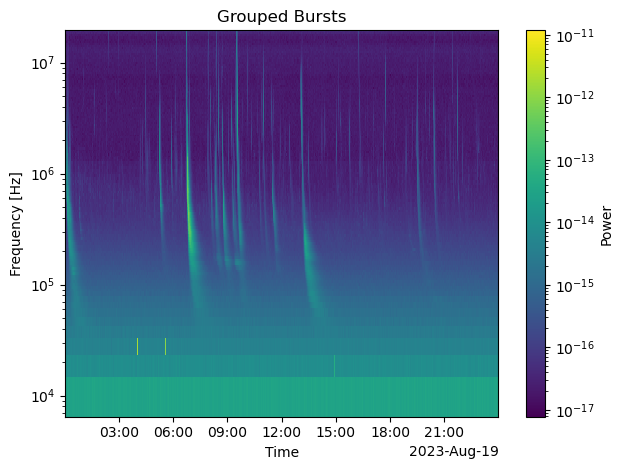

In [32]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_arr, data_arr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
freq_log, freq_log_exp, data_arr_log = convert_data_log(freq_arr, data_arr)

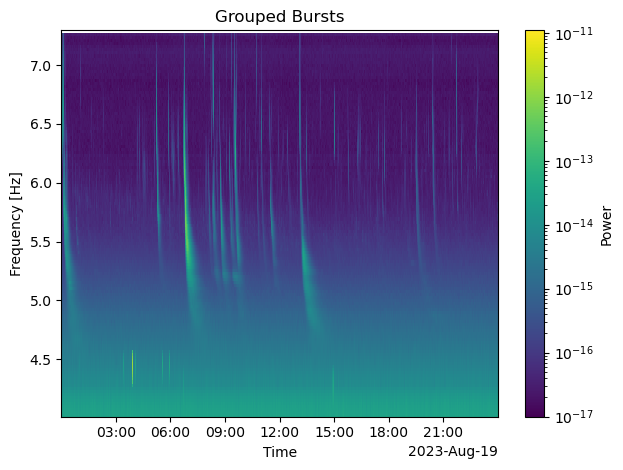

In [34]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr_log.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

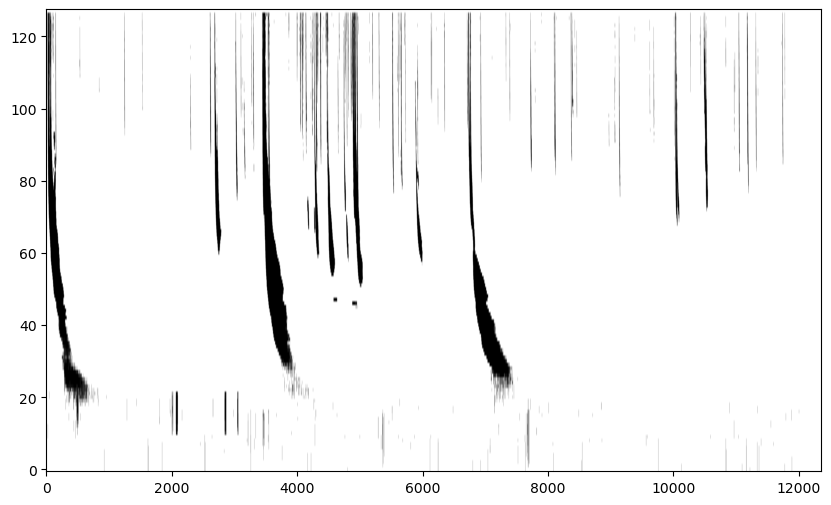

In [35]:
bmap_row_mean = bmap_row_mean_loop_new(times_arr=times_arr, full_data=data_arr_log, min_duration=1)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [36]:
threshold = 10
line_gap = 10
line_length = 120
theta=np.deg2rad(np.linspace(30, 40, 120))

time_diff = 1000
freq_diff = 100000000

lines = hough_detect(bmap_row_mean, data_arr_log, threshold=10, line_gap=50, line_length=60, theta=np.deg2rad(np.linspace(40, 60, 120)))
line_sets, line_sets_actual = line_grouping_new(times_arr, freq_log, lines, time_diff, freq_diff)
line_sets_actual

[(('2023-08-19 00:03:01.586579+00:00', 13448403.584743593),
  ('2023-08-19 00:09:54.027298+00:00', 306244.0206676167)),
 (('2023-08-19 05:13:10.356691+00:00', 10617152.098984437),
  ('2023-08-19 05:20:30.759572+00:00', 365649.2096409403)),
 (('2023-08-19 06:41:50.143653+00:00', 13448403.584743593),
  ('2023-08-19 06:51:09.385414+00:00', 202492.01505329262)),
 (('2023-08-19 07:58:29.906854+00:00', 18071703.899664175),
  ('2023-08-19 08:05:57.300214+00:00', 743109.3456922388)),
 (('2023-08-19 08:39:37.560934+00:00', 12676666.35635252),
  ('2023-08-19 08:53:22.442617+00:00', 30556.692535528306)),
 (('2023-08-19 09:13:10.831419+00:00', 16057123.76350689),
  ('2023-08-19 09:20:38.224779+00:00', 344666.41374003445)),
 (('2023-08-19 11:30:11.685839+00:00', 7020181.2200736515),
  ('2023-08-19 11:37:11.117282+00:00', 324887.7165003882)),
 (('2023-08-19 13:02:28.180100+00:00', 14267123.066429222),
  ('2023-08-19 13:09:55.573704+00:00', 586664.7962841988)),
 (('2023-08-19 19:27:03.898697+00:00', 

<Figure size 1000x600 with 0 Axes>

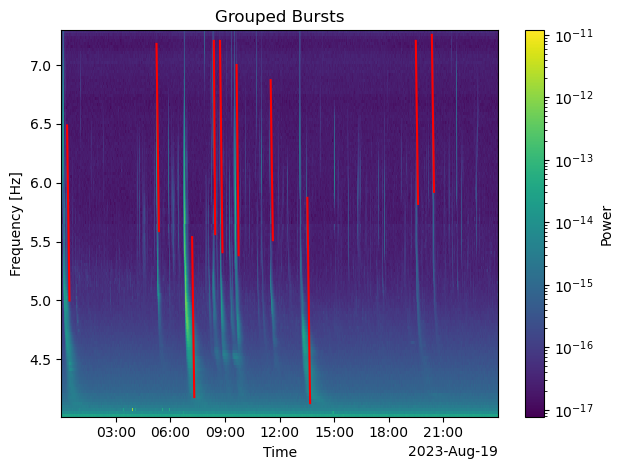

In [37]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0], times_arr[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
freq_gap, times_gap = find_unit(freq_log_exp, times_arr)
freq_gap, times_gap

(0.025665673683947787, 6.990724086761475)

In [39]:
# most popular freq change: 1.5e7Hz
# most popular freq change: 2700s / 45mins

In [40]:
file_path = 'same_side.csv'

all_bursts = pd.read_csv(file_path)

print(all_bursts.head())

       Start time        End time  High frequency (Hz)  Low frequency (Hz)  \
0  2023-1-1/01:30  2023-1-1/04:00           10000000.0             50000.0   
1  2023-1-3/06:25  2023-1-3/09:00           20000000.0             70000.0   
2  2023-1-4/03:14  2023-1-4/03:20           10000000.0            600000.0   
3  2023-1-4/05:53  2023-1-4/06:15           20000000.0            300000.0   
4  2023-1-4/09:19  2023-1-4/09:24           20000000.0            600000.0   

  GOES Flare Notes (corona loop brightening, etc.) Other notes  
0    T     T                                  Loop         NaN  
1    T     T                                  Loop         NaN  
2    F   NaN                                   NaN         NaN  
3    T     T                                  Loop         NaN  
4    F   NaN                                   NaN         NaN  


In [41]:
all_bursts['Freq Change'] = all_bursts['High frequency (Hz)'] - all_bursts['Low frequency (Hz)']
all_bursts

,Start time,End time,High frequency (Hz),Low frequency (Hz),GOES,Flare,"Notes (corona loop brightening, etc.)",Other notes,Freq Change
0,2023-1-1/01:30,2023-1-1/04:00,10000000.0,50000.0,T,T,Loop,NaN,9950000.0
1,2023-1-3/06:25,2023-1-3/09:00,20000000.0,70000.0,T,T,Loop,NaN,19930000.0
2,2023-1-4/03:14,2023-1-4/03:20,10000000.0,600000.0,F,NaN,NaN,NaN,9400000.0
3,2023-1-4/05:53,2023-1-4/06:15,20000000.0,300000.0,T,T,Loop,NaN,19700000.0
4,2023-1-4/09:19,2023-1-4/09:24,20000000.0,600000.0,F,NaN,NaN,NaN,19400000.0
...,...,...,...,...,...,...,...,...,...
478,2023-9-30/15:23,2023-9-30/15:44,20000000.0,200000.0,F,NaN,NaN,NaN,19800000.0
479,2023-9-30/15:36,2023-9-30/16:00,20000000.0,200000.0,T,T,Spot,NaN,19800000.0
480,2023-9-30/15:50,2023-9-30/16:30,20000000.0,200000.0,F,NaN,NaN,NaN,19800000.0
481,2023-9-30/16:20,2023-9-30/17:26,20000000.0,200000.0,T,T,Spot,NaN,19800000.0


In [42]:
freq_change_mean = np.mean(all_bursts['Freq Change'])
freq_change_mean

14718120.082815735

In [43]:
low_freq_mean = np.mean(all_bursts['Low frequency (Hz)'])
low_freq_mean

344405.7971014493

In [44]:
all_bursts['Start time'] = pd.to_datetime(all_bursts['Start time'], format='%Y-%m-%d/%H:%M', errors='coerce')
all_bursts['End time'] = pd.to_datetime(all_bursts['End time'], format='%Y-%m-%d/%H:%M', errors='coerce')
all_bursts['Duration'] = (all_bursts['End time'] - all_bursts['Start time']).dt.total_seconds()
all_bursts

,Start time,End time,High frequency (Hz),Low frequency (Hz),GOES,Flare,"Notes (corona loop brightening, etc.)",Other notes,Freq Change,Duration
0,2023-01-01 01:30:00,2023-01-01 04:00:00,10000000.0,50000.0,T,T,Loop,NaN,9950000.0,9000.0
1,2023-01-03 06:25:00,2023-01-03 09:00:00,20000000.0,70000.0,T,T,Loop,NaN,19930000.0,9300.0
2,2023-01-04 03:14:00,2023-01-04 03:20:00,10000000.0,600000.0,F,NaN,NaN,NaN,9400000.0,360.0
3,2023-01-04 05:53:00,2023-01-04 06:15:00,20000000.0,300000.0,T,T,Loop,NaN,19700000.0,1320.0
4,2023-01-04 09:19:00,2023-01-04 09:24:00,20000000.0,600000.0,F,NaN,NaN,NaN,19400000.0,300.0
...,...,...,...,...,...,...,...,...,...,...
478,2023-09-30 15:23:00,2023-09-30 15:44:00,20000000.0,200000.0,F,NaN,NaN,NaN,19800000.0,1260.0
479,2023-09-30 15:36:00,2023-09-30 16:00:00,20000000.0,200000.0,T,T,Spot,NaN,19800000.0,1440.0
480,2023-09-30 15:50:00,2023-09-30 16:30:00,20000000.0,200000.0,F,NaN,NaN,NaN,19800000.0,2400.0
481,2023-09-30 16:20:00,2023-09-30 17:26:00,20000000.0,200000.0,T,T,Spot,NaN,19800000.0,3960.0


In [45]:
duration_mean = np.mean(all_bursts['Duration'])
duration_mean

2699.503105590062

In [46]:
max(freq_log)

19171883.25974034

In [47]:
target_freq_index = 0
while target_freq_index < len(freq_log) and freq_log[target_freq_index] < low_freq_mean:
    target_freq_index += 1

target_freq_index

59

In [48]:
target_freq_index_reverse = len(freq_log) - target_freq_index
target_freq_index_reverse

69

In [49]:
target_freq = max(freq_log) - freq_change_mean
target_freq

4453763.176924607

In [50]:
target_freq_index = 0
while target_freq_index < len(freq_log) and freq_log[target_freq_index] < target_freq:
    target_freq_index += 1
target_freq_index_reverse = len(freq_log) - target_freq_index
target_freq_index_reverse

25

In [51]:
times_arr_UNX = UTC_to_UNX(times_arr)
times_arr_UNX

array([1.69240321e+09, 1.69240321e+09, 1.69240322e+09, ...,
       1.69248958e+09, 1.69248959e+09, 1.69248960e+09])

In [52]:
target_time = times_arr_UNX[1] + duration_mean
target_time_index = 0
while target_time_index < len(times_arr_UNX) and times_arr_UNX[target_time_index] < target_time:
    target_time_index += 1

target_time_index

388

In [53]:
def hough_angle(freq_change, freq_log, time_duration, times_arr):
    # times in second
    # times_arr in UTC
    target_freq = max(freq_log) - freq_change
    target_freq_index = 0
    while target_freq_index < len(freq_log) and freq_log[target_freq_index] < target_freq:
        target_freq_index += 1
    target_freq_index_reverse = len(freq_log) - target_freq_index

    times_arr_UNX = UTC_to_UNX(times_arr)
    target_time = times_arr_UNX[1] + time_duration
    target_time_index = 0
    while target_time_index < len(times_arr_UNX) and times_arr_UNX[target_time_index] < target_time:
        target_time_index += 1

    angle_rad = math.atan2(-target_freq_index_reverse, target_time_index)
    angle_deg = math.degrees(angle_rad) + 90

    return target_freq_index_reverse, target_time_index, angle_deg

target_freq_index_reverse, target_time_index, angle_deg = hough_angle(freq_change_mean, freq_log, duration_mean, times_arr)
target_freq_index_reverse, target_time_index, angle_deg

(25, 388, 86.31335782704286)

In [54]:
theta=np.deg2rad(np.linspace(angle_deg-10, angle_deg+10, 120))

time_diff = 1000
freq_diff = 100000000

lines = hough_detect(bmap_row_mean, data_arr_log, threshold=10, line_gap=50, line_length=60, theta=theta)
line_sets, line_sets_actual = line_grouping_new(times_arr, freq_log, lines, time_diff, freq_diff)
line_sets_actual

[(('2023-08-19 00:04:18.482339+00:00', 18071703.899664175),
  ('2023-08-19 00:06:10.330740+00:00', 34390.436779852265)),
 (('2023-08-19 06:44:51.897091+00:00', 18071703.899664175),
  ('2023-08-19 06:46:36.755013+00:00', 521265.1388009401)),
 (('2023-08-19 08:18:18.295657+00:00', 18071703.899664175),
  ('2023-08-19 08:19:35.191173+00:00', 521265.1388009401)),
 (('2023-08-19 08:43:21.257736+00:00', 18071703.899664175),
  ('2023-08-19 08:45:06.115658+00:00', 521265.1388009401)),
 (('2023-08-19 09:18:25.404940+00:00', 18071703.899664175),
  ('2023-08-19 09:20:10.262618+00:00', 365649.2096409403)),
 (('2023-08-19 11:30:11.685839+00:00', 7447559.763082143),
  ('2023-08-19 11:32:03.534240+00:00', 28803.19539681081)),
 (('2023-08-19 13:27:31.142668+00:00', 18071703.899664175),
  ('2023-08-19 13:30:04.934188+00:00', 83449.31900330367))]

<Figure size 1000x600 with 0 Axes>

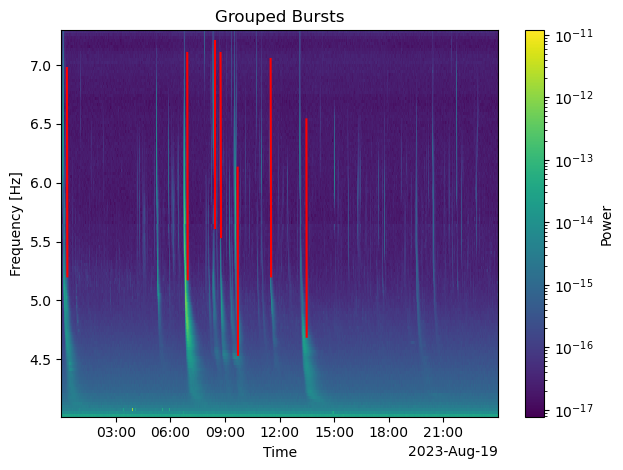

In [55]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0], times_arr[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# lines = hough_detect(bmap_row_mean, data_arr_log, threshold=10, line_gap=10, line_length=50, theta=np.deg2rad(np.linspace(0, 10, 120)))
# # line_sets, line_sets_actual = line_grouping_new(times_arr, freq_log, lines, time_diff, freq_diff)

# plt.figure(figsize=(10, 6))

# fig, ax = plt.subplots()
# p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
# plt.colorbar(p, label='Power')

# for (x0, y0), (x1, y1) in lines:
#     t0, t1 = times_arr[y0], times_arr[y1]
#     f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
#     # print(t0, t1, f0, f1)
#     ax.plot([t0, t1], [f0, f1], color='red')

# plt.xlabel("Time")
# plt.ylabel("Frequency [Hz]")
# # plt.yscale('log')
# plt.title("Grouped Bursts")
# # plt.grid(True)
# plt.tight_layout()
# plt.show()

In [57]:
# plt.figure(figsize=(10, 6))

# fig, ax = plt.subplots()
# p = ax.pcolormesh(times_arr, freq_log_exp, bmap_row_mean.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
# plt.colorbar(p, label='Power')

# for (x0, y0), (x1, y1) in lines:
#     t0, t1 = times_arr[y0], times_arr[y1]
#     f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
#     # print(t0, t1, f0, f1)
#     ax.plot([t0, t1], [f0, f1], color='red')

# plt.xlabel("Time")
# plt.ylabel("Frequency [Hz]")
# # plt.yscale('log')
# plt.title("Grouped Bursts")
# # plt.grid(True)
# plt.tight_layout()
# # plt.show()

In [58]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
# plt.colorbar(p, label='Power')

# p = ax.pcolormesh(times_arr, freq_log_exp, bmap_row_mean.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
# plt.colorbar(p, label='Power')
# plt.show()

In [59]:
import numpy as np
import numpy.linalg as LA
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter
import numpy.linalg as LA

def PJcurvature(x,y):
    """
    input  : the coordinate of the three point
    output : the curvature and norm direction
    refer to https://github.com/peijin94/PJCurvature for detail
    """
    t_a = LA.norm([x[1]-x[0],y[1]-y[0]])
    t_b = LA.norm([x[2]-x[1],y[2]-y[1]])

    M = np.array([
        [1, -t_a, t_a**2],
        [1, 0,    0     ],
        [1,  t_b, t_b**2]])

    a = np.matmul(LA.pinv(M),x)
    b = np.matmul(LA.pinv(M),y)

    kappa = 2*(a[2]*b[1]-b[2]*a[1])/(a[1]**2.+b[1]**2.)**(1.5)
    return kappa, [b[1],-a[1]]/np.sqrt(a[1]**2.+b[1]**2.)


def ACBone(img,x,y,x0,y0,n_iter = 200,d_step=0.2,alpha=25,beta=6000,y_gap=90.,blur_sigma=2.5):
        # print((y0[0]),(y0[1]))
        yy = np.linspace((y0[0]),(y0[1]), int(abs(y0[1]-y0[0])/y_gap))
        # print(int(abs(y0[1]-y0[0])/y_gap))
        # print(yy)
        xx = np.linspace((x0[0]),(x0[1]), len(yy))# +  np.random.normal(0, 0.1, len(yy))

        # blurred = gaussian_filter(img, sigma=blur_sigma)
        blurred = img

        Grad_x = interp2d(x, y, np.gradient(img,axis=1)/(np.max(np.gradient(img,axis=1))), kind='quintic')
        Grad_y = interp2d(x, y, np.gradient(img,axis=0)/(np.max(np.gradient(img,axis=0))), kind='quintic')


        Grad_x_blur = interp2d(x, y, np.gradient(blurred,axis=1)/(np.max(np.gradient(blurred,axis=1))), kind='quintic')
        Grad_y_blur = interp2d(x, y, np.gradient(blurred,axis=0)/(np.max(np.gradient(blurred,axis=0))), kind='quintic')

        xx_new = xx
        yy_new = yy

        idx_img=0
        # print(n_iter)
        for step in range(n_iter):
            kappa_arr = np.zeros(len(xx))
            norm_arr  = np.zeros([len(xx),2])
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # print('xx')
            # print(xx[1:-1])
            # print(xx)
            for idx,val in enumerate(xx[1:-1]):
                # print('idx')
                # print(idx)
                # print('val')
                # print(val)
                ytmp = yy_new[idx:idx+3]
                # print('ytmp')
                # print(ytmp)
                xtmp = xx_new[idx:idx+3]
                # print('xtmp')
                # print(xtmp)
                try: 
                    kappa,norm_l = PJcurvature(xtmp,ytmp)
                    kappa_arr[idx+1] = kappa
                    norm_arr[idx+1,:] = norm_l
                except LinAlgError:
                    pass
                
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # plt.plot(xx_new,kappa_arr)
            # plt.show()
            # plt.plot(xx_new,norm_arr)
            # plt.show()
            
            f_x = beta* kappa_arr*norm_arr[:,0]
            f_x[-1] = -f_x[-2]
            f_x[0] = -f_x[1]
            if step>n_iter/3.5 :
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)
            else:
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)

            #print(alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
            #                for i in np.arange(len(xx_new))])[:,0])
            #yy_new = yy_new+ d_step/1000* (alpha * np.array([Grad_y(xx_new[i],yy_new[i])
            #                                            for i in np.arange(len(xx_new))])[:,0])

        img_xy = interp2d(x, y, img, kind='quintic')
        flux = np.array([img_xy(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0]

        return xx_new,yy_new,flux

In [60]:
img = data_arr.T
x = UTC_to_UNX(times_arr)
y = freq_log

x0 = (x[3335], x[3560])
y0 = (y[125], y[40])

xx, yy, flux = ACBone(img, x, y, x0, y0)
xx, yy, flux

(array([1.69242652e+09, 1.69242652e+09, 1.69242652e+09, ...,
        1.69242809e+09, 1.69242809e+09, 1.69242809e+09]),
 array([17034658.38032442, 17034568.37984149, 17034478.37935856, ...,
          112317.57730743,   112227.57682449,   112137.57634156]),
 array([2.42749111e-17, 2.42664236e-17, 2.42579435e-17, ...,
        4.02485826e-14, 4.07090927e-14, 4.11732958e-14]))

In [61]:
line_sets[0]

((46, 168), (115, 155))

In [62]:
img = data_arr_log

x = freq_log_exp
y = UTC_to_UNX(times_arr)

(x0_idx, y0_idx), (x1_idx, y1_idx) = line_sets[0]

x0 = [x[x0_idx], x[x1_idx]]
y0 = [y[y0_idx], y[y1_idx]]
# print(y[y1_idx] - y[y0_idx])
# print(int(abs(y0[1]-y0[0])/90))

xx_new, yy_new, flux = ACBone(img, x, y, x0, y0, y_gap=1)